In [ ]:
!pip install TA-Lib pandas numpy matplotlib seaborn pyarrow --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 25.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = "/content/drive/MyDrive/BTC_USDT_1h_cleaned.parquet"
df = pd.read_parquet(filepath)
df.head()

,timestamp,low,high,open,volume,close,wick_anomaly_flag
0,2020-07-01 00:00:00,9080.10,9138.16,9138.08,1737.641899,9122.00,False
1,2020-07-01 01:00:00,9101.00,9131.73,9121.99,792.511246,9125.00,False
2,2020-07-01 02:00:00,9112.87,9146.67,9125.00,1075.678867,9135.11,False
3,2020-07-01 03:00:00,9113.11,9141.66,9135.10,672.281750,9138.59,False
4,2020-07-01 04:00:00,9138.17,9162.85,9138.55,1116.286467,9147.30,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43843 entries, 0 to 43842
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          43843 non-null  datetime64[ms]
 1   low                43843 non-null  float64       
 2   high               43843 non-null  float64       
 3   open               43843 non-null  float64       
 4   volume             43843 non-null  float64       
 5   close              43843 non-null  float64       
 6   wick_anomaly_flag  43843 non-null  bool          
dtypes: bool(1), datetime64[ms](1), float64(5)
memory usage: 2.0 MB


In [ ]:
df.describe()

,timestamp,low,high,open,volume,close
count,43843,43843.000000,43843.000000,43843.000000,43843.000000,43843.000000
mean,2022-12-31 13:11:59.622000,44801.683912,45190.586708,44999.897951,3303.913655,45002.145671
min,2020-07-01 00:00:00,8893.030000,9034.780000,9012.000000,0.000000,9012.000000
25%,2021-09-30 21:30:00,25159.470000,25601.205000,25389.340000,915.215940,25422.740000
50%,2022-12-31 14:00:00,39491.990000,39899.480000,39709.190000,1734.251510,39710.150000
75%,2024-04-01 06:30:00,60778.000000,61256.035000,61026.375000,3611.712810,61027.720000
max,2025-07-01 23:00:00,111382.970000,111980.000000,111780.840000,137207.188600,111780.840000
std,NaN,25523.495146,25698.382038,25611.133080,4698.760308,25612.185924


In [ ]:
# Returns and target creation

# simple return
df['return_1h'] = (
    df['close'].pct_change()
)


# log return
df['log_return'] = (
    np.log(df['close'])
    -
    np.log(df['close'].shift(1))
)


# multi-period momentum returns
df['log_return_3h'] = (
    np.log(df['close'])
    -
    np.log(df['close'].shift(3))
)


df['log_return_6h'] = (
    np.log(df['close'])
    -
    np.log(df['close'].shift(6))
)


df['log_return_12h'] = (
    np.log(df['close'])
    -
    np.log(df['close'].shift(12))
)


df['log_return_24h'] = (
    np.log(df['close'])
    -
    np.log(df['close'].shift(24))
)

In [ ]:
#Price action features

df['return_1h'] = (
    df['close']
    .pct_change()
)


df['body_pct'] = (
    abs(df['close']-df['open'])
    /
    (df['high']-df['low'])
)


df['upper_wick_pct'] = (
    (df['high']-df[['open','close']].max(axis=1))
    /
    (df['high']-df['low'])
)


df['lower_wick_pct'] = (
    (df[['open','close']].min(axis=1)-df['low'])
    /
    (df['high']-df['low'])
)


df['range_pct'] = (
    (df['high']-df['low'])
    /
    df['close']
)

In [ ]:
#Momentum Features

close = df['close'].values


df['RSI'] = talib.RSI(
    close,
    timeperiod=14
)


df['ROC'] = talib.ROC(
    close,
    timeperiod=12
)


macd, signal, hist = talib.MACD(close)

df['MACD_hist'] = hist


slowk, slowd = talib.STOCH(
    df['high'],
    df['low'],
    df['close']
)

df['stoch_k'] = slowk
df['stoch_d'] = slowd

In [ ]:
#Trend Features

df['EMA_20'] = talib.EMA(
    close,
    timeperiod=20
)


df['EMA_50'] = talib.EMA(
    close,
    timeperiod=50
)


df['EMA_ratio'] = (
    df['EMA_20']
    /
    df['EMA_50']
)


df['ADX'] = talib.ADX(
    df['high'],
    df['low'],
    df['close'],
    timeperiod=14
)


df['price_to_EMA'] = (
    df['close']
    /
    df['EMA_50']
)

In [ ]:
#Volatility Features

df['ATR'] = talib.ATR(
    df['high'],
    df['low'],
    df['close'],
    timeperiod=14
)


df['ATR_pct'] = (
    df['ATR']
    /
    df['close']
)


df['rolling_volatility'] = (
    df['log_return']
    .rolling(24)
    .std()
)


upper, middle, lower = talib.BBANDS(
    close
)


df['BB_width'] = (
    (upper-lower)
    /
    middle
)

In [ ]:
#Volume Features

df['volume_change'] = (
    df['volume']
    .pct_change()
)


df['volume_zscore'] = (
    (
    df['volume']
    -
    df['volume'].rolling(48).mean()
    )
    /
    df['volume'].rolling(48).std()
)


df['OBV'] = talib.OBV(
    df['close'],
    df['volume']
)

In [ ]:
#Regime Features

df['rolling_sharpe'] = (
    df['log_return']
    .rolling(72)
    .mean()
    /
    df['log_return']
    .rolling(72)
    .std()
)


df['trend_strength'] = (
    abs(df['EMA_ratio']-1)
)

In [ ]:
# ==========================
# Additional Market Features
# ==========================


# Rolling return statistics

df['return_mean_24h'] = (
    df['log_return']
    .rolling(24)
    .mean()
)


df['return_std_24h'] = (
    df['log_return']
    .rolling(24)
    .std()
)



# Volatility regime

df['volatility_ratio'] = (

    df['return_std_24h']

    /

    df['return_std_24h']
    .rolling(168)
    .mean()

)



# Distance from recent high/low

df['distance_from_high_24h'] = (

    df['close']

    /

    df['high']
    .rolling(24)
    .max()

) - 1



df['distance_from_low_24h'] = (

    df['close']

    /

    df['low']
    .rolling(24)
    .min()

) - 1




# Candle direction

df['candle_direction'] = np.where(
    df['close'] > df['open'],
    1,
    -1
)



# Consecutive momentum

df['up_streak'] = (

    df['candle_direction']
    .rolling(6)
    .sum()

)



# Volume-price interaction

df['volume_return'] = (

    df['volume']

    *

    df['log_return']

)



# Relative volume

df['relative_volume'] = (

    df['volume']

    /

    df['volume']
    .rolling(48)
    .mean()

)



# High-low volatility

df['hl_volatility'] = (

    np.log(df['high'])

    -

    np.log(df['low'])

)



# Close position inside candle range

df['close_location'] = (

    (df['close']-df['low'])

    /

    (df['high']-df['low'])

)

In [ ]:
features = [


# ==================
# Returns / Momentum
# ==================

'log_return',

'log_return_3h',

'log_return_6h',

'log_return_12h',

'log_return_24h',

'RSI',

'ROC',

'MACD_hist',

'stoch_k',

'stoch_d',



# ==================
# Trend
# ==================

'EMA_ratio',

'ADX',

'price_to_EMA',

'trend_strength',



# ==================
# Volatility
# ==================

'ATR_pct',

'rolling_volatility',

'BB_width',

'return_std_24h',

'volatility_ratio',

'hl_volatility',



# ==================
# Price Action
# ==================

'body_pct',

'upper_wick_pct',

'lower_wick_pct',

'range_pct',

'close_location',

'distance_from_high_24h',

'distance_from_low_24h',



# ==================
# Volume
# ==================

'volume_change',

'volume_zscore',

'OBV',

'relative_volume',

'volume_return',



# ==================
# Market Regime
# ==================

'rolling_sharpe',

'return_mean_24h',

'up_streak',



# ==================
# Existing anomaly
# ==================

'wick_anomaly_flag'


]


len(features)

36

# Correlation Filtering

Purpose:

Remove features giving almost identical information.

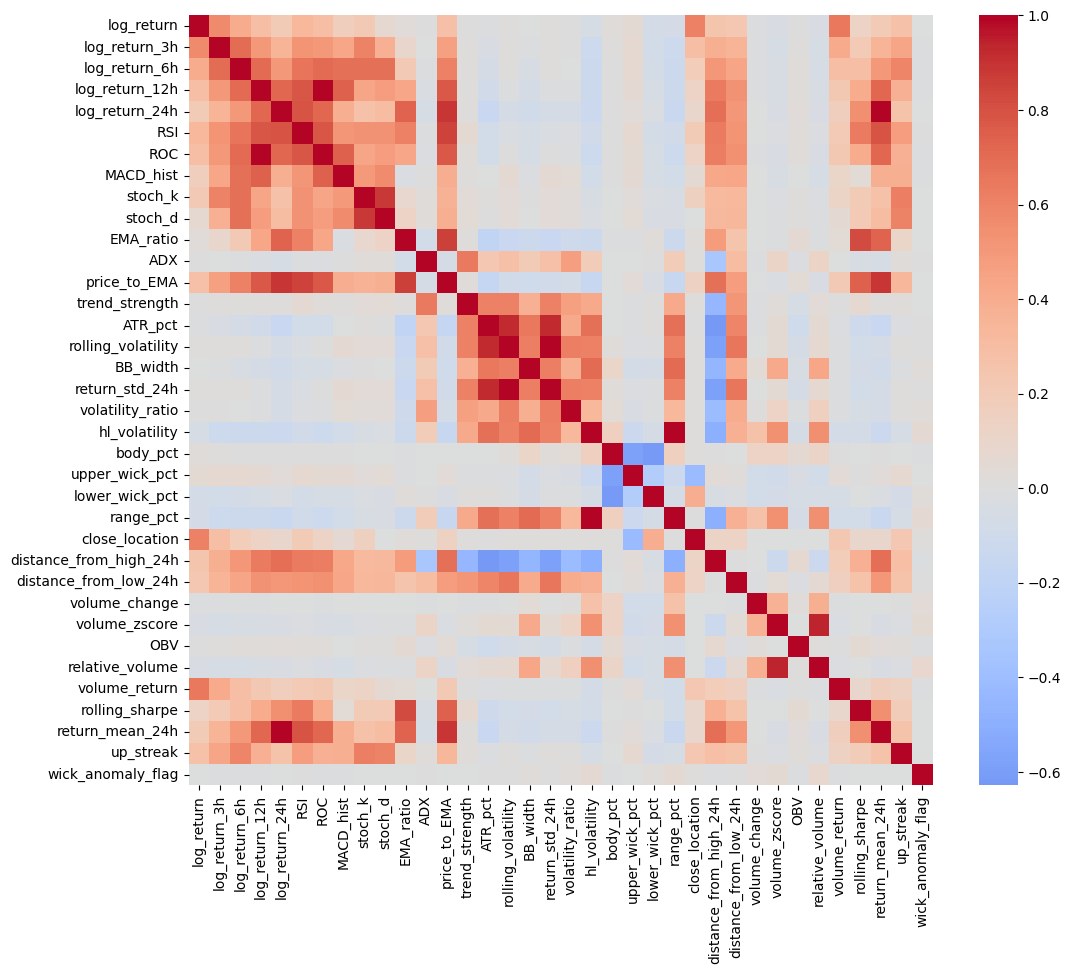

In [ ]:
corr = df[features].corr()


plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.show()

## Key Observations from the Correlation Heatmap

The correlation analysis identified several groups of highly correlated features, indicating that many features capture similar information.

- **Return features (`log_return_*h`)** form a highly correlated cluster. Retaining one or two representative time horizons is sufficient.
- **`stoch_k` and `stoch_d`** are nearly perfectly correlated, so only one of them is required.
- **`price_to_EMA`, `trend_strength`, and `EMA_ratio`** capture similar trend information and are largely redundant.
- **`rolling_volatility`, `ATR_pct`, `BB_width`, and `return_std_24h`** all measure market volatility, allowing a smaller subset to represent this category.
- **`volume_change`, `volume_zscore`, `relative_volume`, and `volume_return`** form a correlated group, where one or two normalized volume indicators are sufficient.
- **`distance_from_high_24h` and `distance_from_low_24h`** are strongly negatively correlated; however, both are retained as they provide complementary information about the asset's position within its recent trading range.
- **`rolling_sharpe` and `return_mean_24h`** are highly correlated, making a single representative feature adequate.


# Feature Selection

To reduce redundancy and improve learning efficiency, feature selection was performed using the correlation heatmap. Highly correlated features were grouped, and representative features were retained based on interpretability, stability, and relevance for reinforcement learning.

## Selected Features

### Returns & Momentum
| Feature | Reason |
|----------|----------|
| `log_return` | Immediate price movement signal |
| `log_return_6h` | Medium-term momentum |
| `RSI` | Overbought/oversold conditions |

**Dropped:** `log_return_3h`, `log_return_12h`, `log_return_24h`, `ROC`, `MACD_hist`, `stoch_d`

---

### Trend
| Feature | Reason |
|----------|----------|
| `EMA_ratio` | Normalized trend direction |
| `ADX` | Trend strength |

**Dropped:** `price_to_EMA`, `trend_strength`

---

### Volatility
| Feature | Reason |
|----------|----------|
| `ATR_pct` | Normalized volatility measure |
| `volatility_ratio` | Volatility regime changes |

**Dropped:** `rolling_volatility`, `BB_width`, `return_std_24h`, `hl_volatility`

---

### Price Action
| Feature | Reason |
|----------|----------|
| `close_location` | Candle closing position within range |
| `distance_from_high_24h` | Proximity to recent highs |
| `distance_from_low_24h` | Proximity to recent lows |
| `body_pct` | Candle conviction |

**Dropped:** `upper_wick_pct`, `lower_wick_pct`, `range_pct`

---

### Volume
| Feature | Reason |
|----------|----------|
| `volume_zscore` | Normalized volume activity |
| `OBV` | Directional volume flow |

**Dropped:** `volume_change`, `relative_volume`, `volume_return`

---

### Market Regime
| Feature | Reason |
|----------|----------|
| `rolling_sharpe` | Risk-adjusted performance |
| `up_streak` | Trend persistence |

**Dropped:** `return_mean_24h`

---

### Anomaly Detection
| Feature | Reason |
|----------|----------|
| `wick_anomaly_flag` | Independent anomaly signal |

---

## Final Feature Set

```python
selected_features = [
    "log_return",
    "log_return_6h",
    "RSI",

    "EMA_ratio",
    "ADX",

    "ATR_pct",
    "volatility_ratio",

    "close_location",
    "distance_from_high_24h",
    "distance_from_low_24h",
    "body_pct",

    "volume_zscore",
    "OBV",

    "rolling_sharpe",
    "up_streak",

    "wick_anomaly_flag"
]
```

The final feature set contains **16 features**, preserving information from momentum, trend, volatility, volume, price action, market regime, and anomaly detection while minimizing redundancy.